<a href="https://colab.research.google.com/github/AyushNegi785/bakanae-disease-detection/blob/main/mobilenetV3_large.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Prepare File List and Labels ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']): # 0: Bakanae, 1: Healthy
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [ ]:
def build_mobilenet_v3():
    # MobileNetV3Large is the "IoT Powerhouse"
    base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        # Built-in scaling for MobileNetV3
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- MobileNetV3 Fold {fold+1}/{NUM_FOLDS} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx]))
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx]))

    train_ds = train_ds.map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = val_ds.map(decode_img).batch(BATCH_SIZE)

    model = build_mobilenet_v3()
    model.fit(train_ds, epochs=10, verbose=0)

    # Collect Probabilities for AUC
    y_true = all_labels[val_idx]
    y_probs = model.predict(val_ds).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Store metrics for validation block
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)
    roc_curves.append((fpr, tpr, fold_auc))

    fold_results.append({
        'Fold': fold+1,
        'ACC': accuracy_score(y_true, y_pred),
        'PREC': precision_score(y_true, y_pred),
        'RECALL': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': fold_auc
    })
    all_cms.append(confusion_matrix(y_true, y_pred))

print("\nCross-Validation Training Complete.")


--- MobileNetV3 Fold 1/5 ---
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step

--- MobileNetV3 Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

--- MobileNetV3 Fold 3/5 ---


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

--- MobileNetV3 Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

--- MobileNetV3 Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Cross-Validation Training Complete.



--- MobileNetV3 5-Fold Summary ---
 Fold      ACC     PREC   RECALL       F1      AUC
    1 0.990431 0.980198 1.000000 0.990000 0.999449
    2 0.961722 0.980583 0.943925 0.961905 0.990563
    3 0.980769 1.000000 0.958333 0.978723 0.990420
    4 0.995192 1.000000 0.991379 0.995671 1.000000
    5 0.985577 0.982759 0.991304 0.987013 0.998223

--- Final IoT Scorecard (Averages) ---
ACC       0.982738
PREC      0.988708
RECALL    0.976988
F1        0.982662
AUC       0.995731
dtype: float64


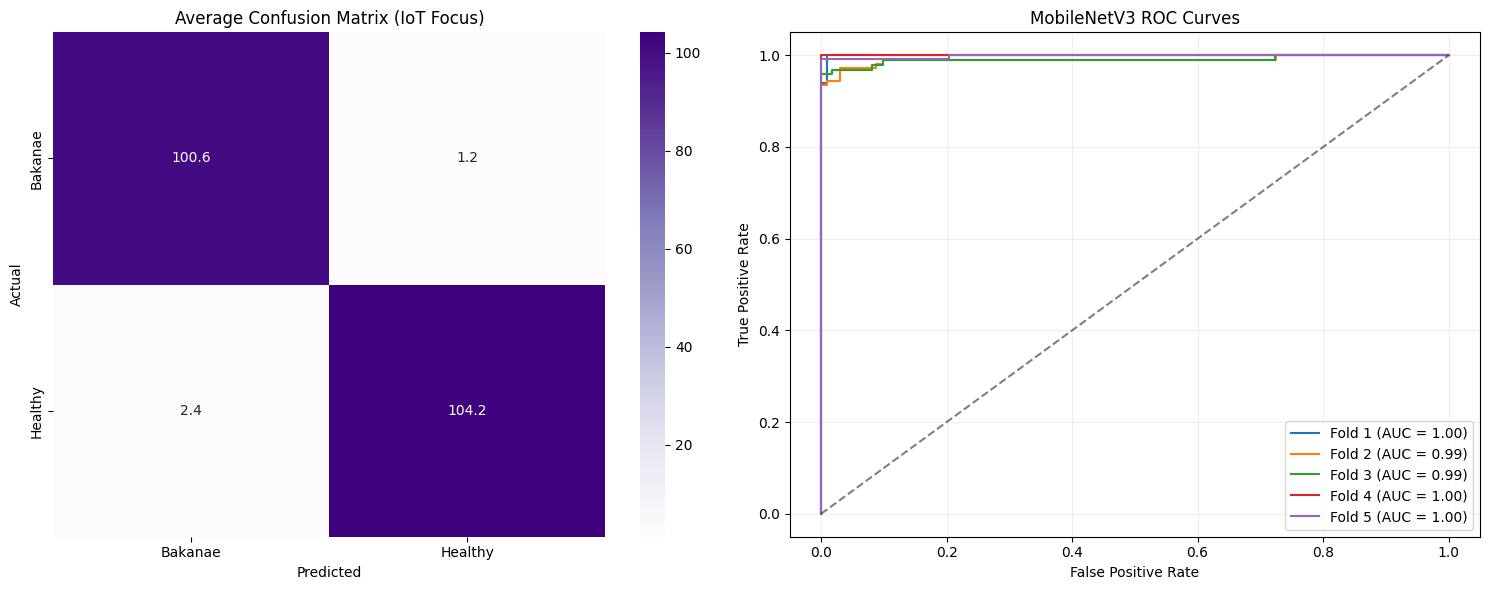

In [ ]:
# --- 1. Results Table ---
results_df = pd.DataFrame(fold_results)
print("\n--- MobileNetV3 5-Fold Summary ---")
print(results_df.to_string(index=False))
print("\n--- Final IoT Scorecard (Averages) ---")
print(results_df[['ACC', 'PREC', 'RECALL', 'F1', 'AUC']].mean())

# --- 2. Visualization ---
plt.figure(figsize=(15, 6))

# Average Confusion Matrix
plt.subplot(1, 2, 1)
avg_cm = np.mean(all_cms, axis=0)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Average Confusion Matrix (IoT Focus)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curves
plt.subplot(1, 2, 2)
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('MobileNetV3 ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. File Loading ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MOBILENET-V3 LARGE MODEL PARAMETERS


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,489 (11.90 MB)

 Trainable params: 123,137 (481.00 KB)

 Non-trainable params: 2,996,352 (11.43 MB)



--- FOLD 1 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step
Train Time: 603.41s | Test Time: 28.4913s
Metrics -> Acc: 0.9904 | F1: 0.9900 | Recall: 1.0000


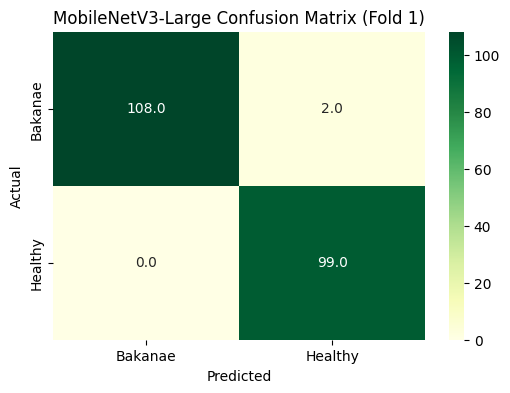


--- FOLD 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Train Time: 515.49s | Test Time: 20.5095s
Metrics -> Acc: 0.9617 | F1: 0.9619 | Recall: 0.9439


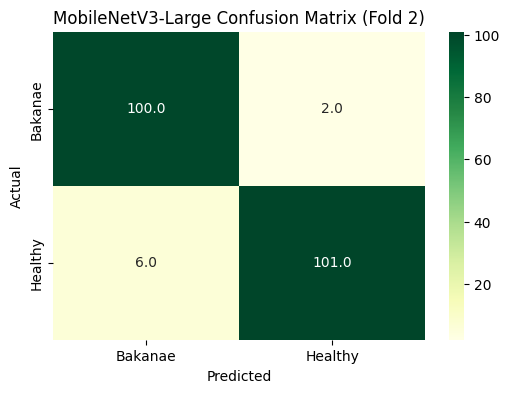


--- FOLD 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Train Time: 550.78s | Test Time: 20.4901s
Metrics -> Acc: 0.9808 | F1: 0.9787 | Recall: 0.9583


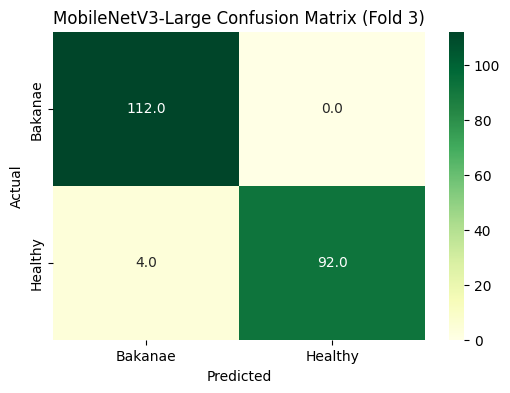


--- FOLD 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Train Time: 472.43s | Test Time: 20.4793s
Metrics -> Acc: 0.9952 | F1: 0.9957 | Recall: 0.9914


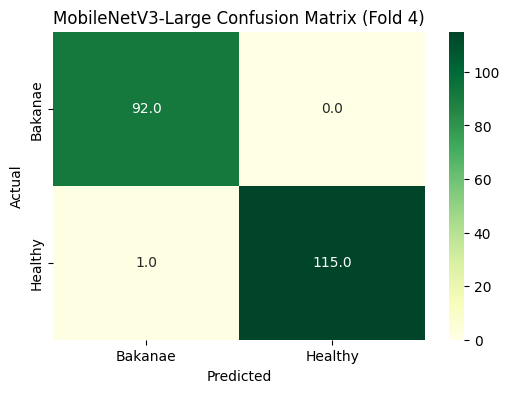


--- FOLD 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Train Time: 616.20s | Test Time: 20.4912s
Metrics -> Acc: 0.9856 | F1: 0.9870 | Recall: 0.9913


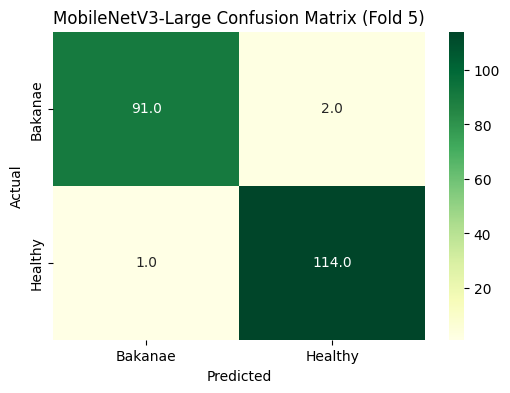

In [ ]:
def plot_cm_image(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='YlGn',
                xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def build_mobilenet_v3_large():
    # Load Large variant optimized for higher precision on mobile devices
    base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 1. Show Parameter Breakdown
temp_model = build_mobilenet_v3_large()
print("\n" + "="*50)
print("MOBILENET-V3 LARGE MODEL PARAMETERS")
temp_model.summary()
print("="*50 + "\n")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- FOLD {fold+1} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_mobilenet_v3_large()

    # 2. Measure Training Duration
    start_train = time.time()
    model.fit(train_ds, epochs=10, verbose=0)
    train_duration = time.time() - start_train

    # 3. Measure Inference (Test) Duration
    start_test = time.time()
    y_probs = model.predict(val_ds).ravel()
    test_duration = time.time() - start_test

    y_true = all_labels[val_idx]
    y_pred = (y_probs > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)

    print(f"Train Time: {train_duration:.2f}s | Test Time: {test_duration:.4f}s")
    print(f"Metrics -> Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")

    # Print Confusion Matrix image after each fold
    plot_cm_image(cm, f'MobileNetV3-Large Confusion Matrix (Fold {fold+1})')

    all_cms.append(cm)
    roc_curves.append((fpr, tpr, fold_auc))
    fold_results.append({
        'ACC': acc, 'F1': f1, 'RECALL': rec, 'AUC': fold_auc,
        'TRAIN_T': train_duration, 'TEST_T': test_duration
    })


##################################################
FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V3 LARGE)
##################################################
Avg Accuracy:      0.9827
Avg F1-Score:      0.9827
Avg Recall:        0.9770
Avg AUC-ROC:       0.9960
Avg Training Time: 551.66s
Avg Inference Time:22.0923s
##################################################


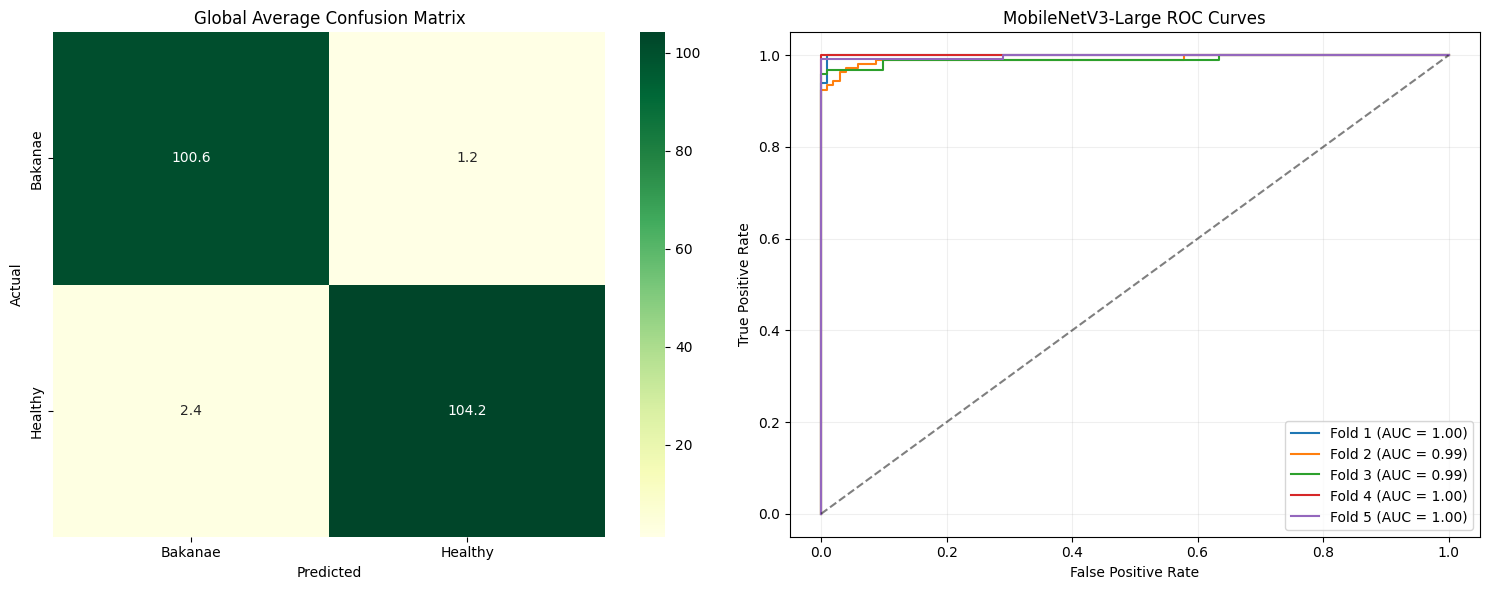

In [ ]:
results_df = pd.DataFrame(fold_results)
avg_cm = np.mean(all_cms, axis=0)

print("\n" + "#"*50)
print("FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V3 LARGE)")
print("#"*50)
print(f"Avg Accuracy:      {results_df['ACC'].mean():.4f}")
print(f"Avg F1-Score:      {results_df['F1'].mean():.4f}")
print(f"Avg Recall:        {results_df['RECALL'].mean():.4f}")
print(f"Avg AUC-ROC:       {results_df['AUC'].mean():.4f}")
print(f"Avg Training Time: {results_df['TRAIN_T'].mean():.2f}s")
print(f"Avg Inference Time:{results_df['TEST_T'].mean():.4f}s")
print("#"*50)

# Final Visualizations
plt.figure(figsize=(15, 6))

# Subplot: Average Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='YlGn',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Global Average Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Subplot: Combined ROC Curves
plt.subplot(1, 2, 2)
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('MobileNetV3-Large ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()